#### Import libraries

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler,LabelEncoder
from sklearn.tree import DecisionTreeClassifier

In [168]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### Null values

In [169]:
model = DecisionTreeClassifier(criterion="entropy",random_state=42)
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
null_value = df.isnull().sum()

if null_value.sum() == 0:
    print("No null values.")
else:
    print("Null values found:")
    print(null_value[null_value > 0])

No null values.


#### Feature Engineering

In [170]:
scalar = StandardScaler()
label = LabelEncoder()
X = scalar.fit_transform(X)
y = label.fit_transform(y)

In [171]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

(112, 4) (38, 4) (112,) (38,)


#### Evaluation metrics

Confusion Matrix:  [[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
Accuracy:  0.9736842105263158


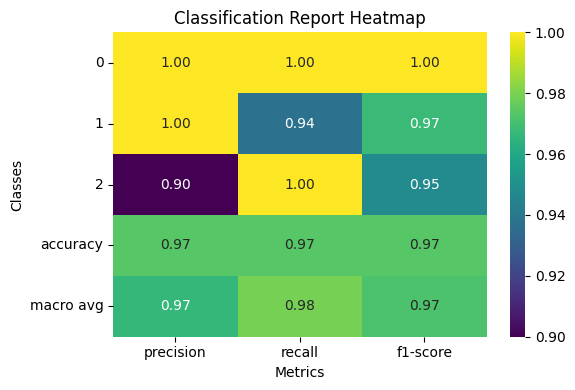

In [ ]:
confuse = confusion_matrix(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)

print("Confusion Matrix: ", confuse)
print("Accuracy: ", accuracy)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(6, 4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='viridis', fmt='.2f')
plt.title("Classification Report Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.tight_layout()
plt.show()

#### Tree structure

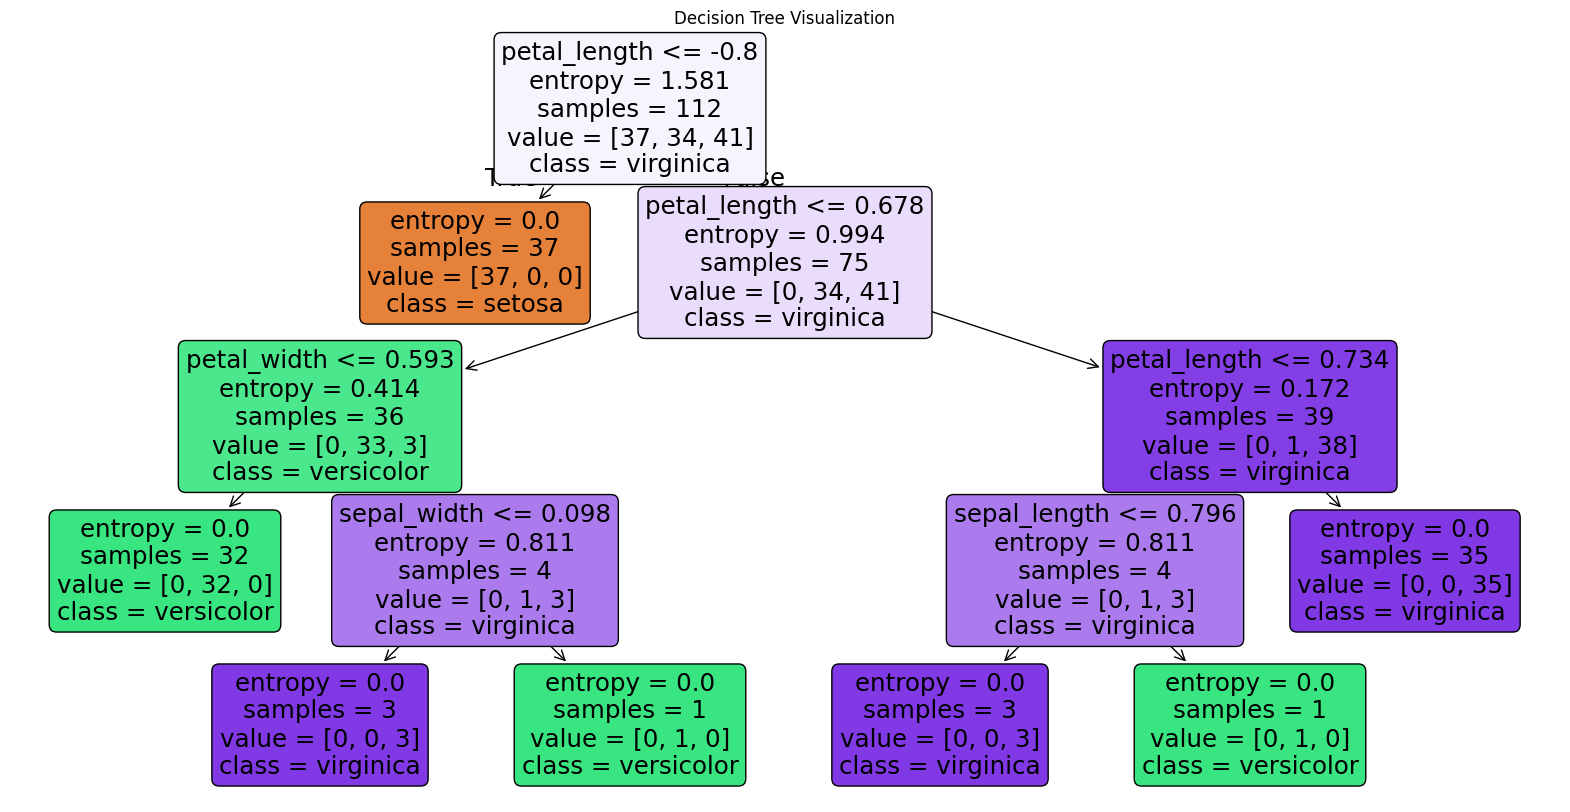

In [173]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=df.columns[:-1], class_names=label.classes_, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

#### Tree depth 

#####

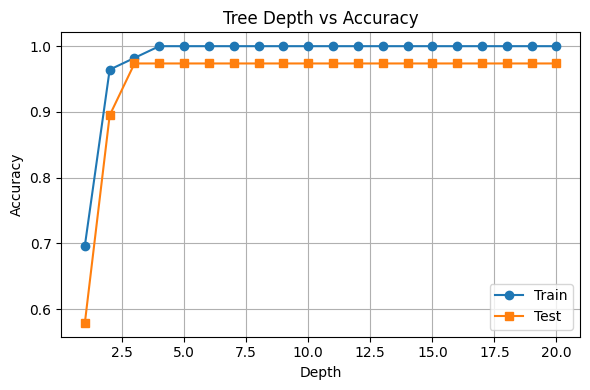

In [174]:

train_accuracies = []
test_accuracies = []
depths = range(1, 21)

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

# Smaller Plot
plt.figure(figsize=(6,4))
plt.plot(depths, train_accuracies, label="Train", marker='o')
plt.plot(depths, test_accuracies, label="Test", marker='s')
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Tree Depth vs Accuracy")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()
